In [247]:
import yfinance as yf
import pandas as pd
import ta

In [248]:
# 1. 데이터 다운로드
ticker = "AMD"
df = yf.download(ticker, start="2020-04-15", end="2025-06-25", interval="1d")

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/432486367.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-04-15", end="2025-06-25", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [249]:
# 2. 다중컬럼 처리
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(0)
    df.columns.name = None

df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

In [250]:
# 기술적 지표 추가
df_ta = ta.add_all_ta_features(
    df,
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True  # NaN 값 보완
)

/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [251]:
# 추세 기반 지표
trend_features = ['trend_macd', 'trend_macd_signal', 'trend_macd_diff',
                  'trend_ema_fast', 'trend_ema_slow', 'trend_sma_fast', 'trend_sma_slow']

# 변동성 기반 지표
volatility_features = ['volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw']

# 모멘텀 기반 지표
momentum_features = ['momentum_rsi', 'momentum_stoch_rsi', 
                     ]

# 거래량 기반 지표 (주의 필요)
volume_features = ['volume_obv', 'volume_adi', 'volume_cmf']


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:17: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:17: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:17: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:17: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:17: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykern

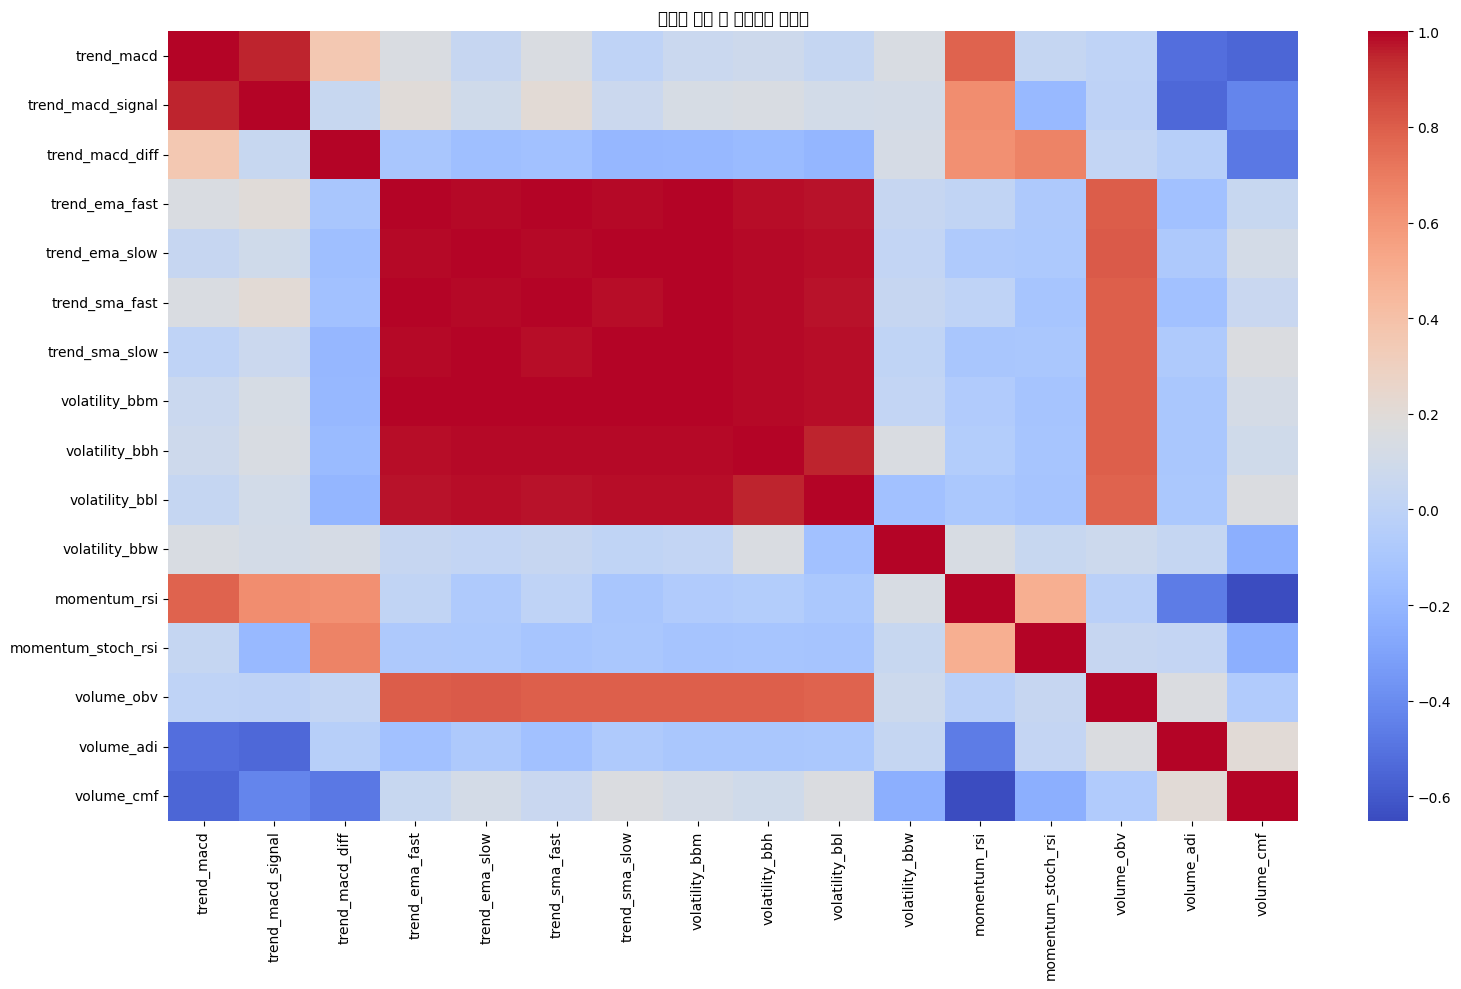

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:23: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:23: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:23: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3135518770.py:23: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipyker

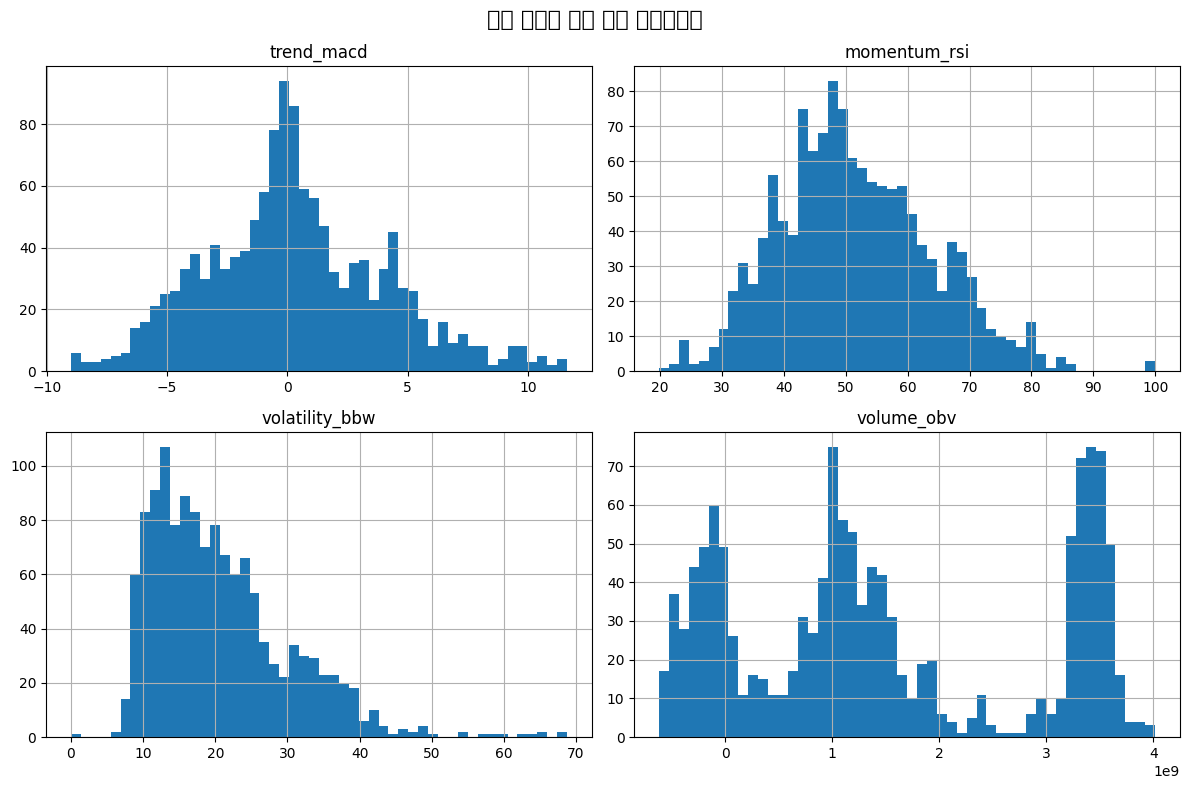

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

# 클러스터링 후보 컬럼 조합
eda_features = trend_features + volatility_features + momentum_features + volume_features

# 시각화를 위한 데이터프레임 구성
eda_df = df_ta[eda_features].copy()

# 결측치 제거 (fillna로 이미 처리했지만 재확인)
eda_df = eda_df.dropna()

# 상관관계 heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(eda_df.corr(), annot=False, cmap='coolwarm')
plt.title("기술적 지표 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

# 대표지표 히스토그램 예시
eda_df[['trend_macd', 'momentum_rsi', 'volatility_bbw', 'volume_obv']].hist(bins=50, figsize=(12, 8))
plt.suptitle("대표 기술적 지표 분포 히스토그램", fontsize=16)
plt.tight_layout()
plt.show()


In [253]:
"""
EDA 결과 분석 요약
🔹 상관관계 히트맵 해석:

trend_ema_fast, trend_ema_slow, trend_sma_fast, trend_sma_slow 간에는 거의 완전한 양의 상관관계 → 중복 가능성 매우 큼
trend_macd, trend_macd_diff 등은 RSI, OBV, CMF 등과는 상관관계 낮음 → 의미 있는 분리 가능성
volume_adi, volume_cmf 간에는 상관도가 꽤 높고, volume_obv는 상대적으로 다른 거래량 지표들과는 덜 연관
🔹 히스토그램 분포 해석:

trend_macd: 정규분포에 가까움, 클러스터링에 적합
momentum_rsi: RSI답게 0~100 내에서 구간 횡보, 뚜렷한 구간 특징을 제공 → 유효
volatility_bbw: 치우친 분포, 극단적 변동성 구간 구별 가능
volume_obv: 계단식 분포 + 단조 증가 누적형 → 군집의 구분력이 떨어질 가능성


"""

'\nEDA 결과 분석 요약\n🔹 상관관계 히트맵 해석:\n\ntrend_ema_fast, trend_ema_slow, trend_sma_fast, trend_sma_slow 간에는 거의 완전한 양의 상관관계 → 중복 가능성 매우 큼\ntrend_macd, trend_macd_diff 등은 RSI, OBV, CMF 등과는 상관관계 낮음 → 의미 있는 분리 가능성\nvolume_adi, volume_cmf 간에는 상관도가 꽤 높고, volume_obv는 상대적으로 다른 거래량 지표들과는 덜 연관\n🔹 히스토그램 분포 해석:\n\ntrend_macd: 정규분포에 가까움, 클러스터링에 적합\nmomentum_rsi: RSI답게 0~100 내에서 구간 횡보, 뚜렷한 구간 특징을 제공 → 유효\nvolatility_bbw: 치우친 분포, 극단적 변동성 구간 구별 가능\nvolume_obv: 계단식 분포 + 단조 증가 누적형 → 군집의 구분력이 떨어질 가능성\n\n\n'

In [254]:
#상관분석 이후 선택한 피쳐 목록

from sklearn.preprocessing import StandardScaler

# 1. 사용할 지표 선택
selected_features = [
    'trend_macd',
    'trend_macd_diff',
    'volatility_bbw',
    'momentum_rsi',
    'volume_cmf',
    'volume_obv'  # 여기서 파생변수 만들 예정
]

# 2. 데이터프레임 복사 및 차분 생성
cluster_df = df_ta[selected_features].copy()
cluster_df['volume_obv_diff'] = cluster_df['volume_obv'].diff()

# 3. 클러스터링용 최종 컬럼 선택
final_features = ['trend_macd', 'trend_macd_diff', 'volatility_bbw',
                  'momentum_rsi', 'volume_cmf', 'volume_obv_diff']

# 4. 결측치 제거
cluster_df = cluster_df[final_features].dropna()

# 5. 스케일링 (StandardScaler)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# 스케일링 결과를 다시 DataFrame으로 변환
scaled_df = pd.DataFrame(scaled_features, index=cluster_df.index, columns=final_features)



In [255]:
#다양한 군집 형성을 위해 kmeans 군집분석 선택 후 n 은 임의로 설정. 기본값은 12 -> 군집 구간별로 다양하게 형성하기 위함. 필요 시 조정 가능.

In [256]:
from sklearn.cluster import KMeans

# 1. 클러스터 수 설정
n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# 2. 클러스터 할당
scaled_df['cluster'] = kmeans.fit_predict(scaled_df)


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3742738694.py:26: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3742738694.py:26: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3742738694.py:26: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3742738694.py:26: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3742738694.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipyker

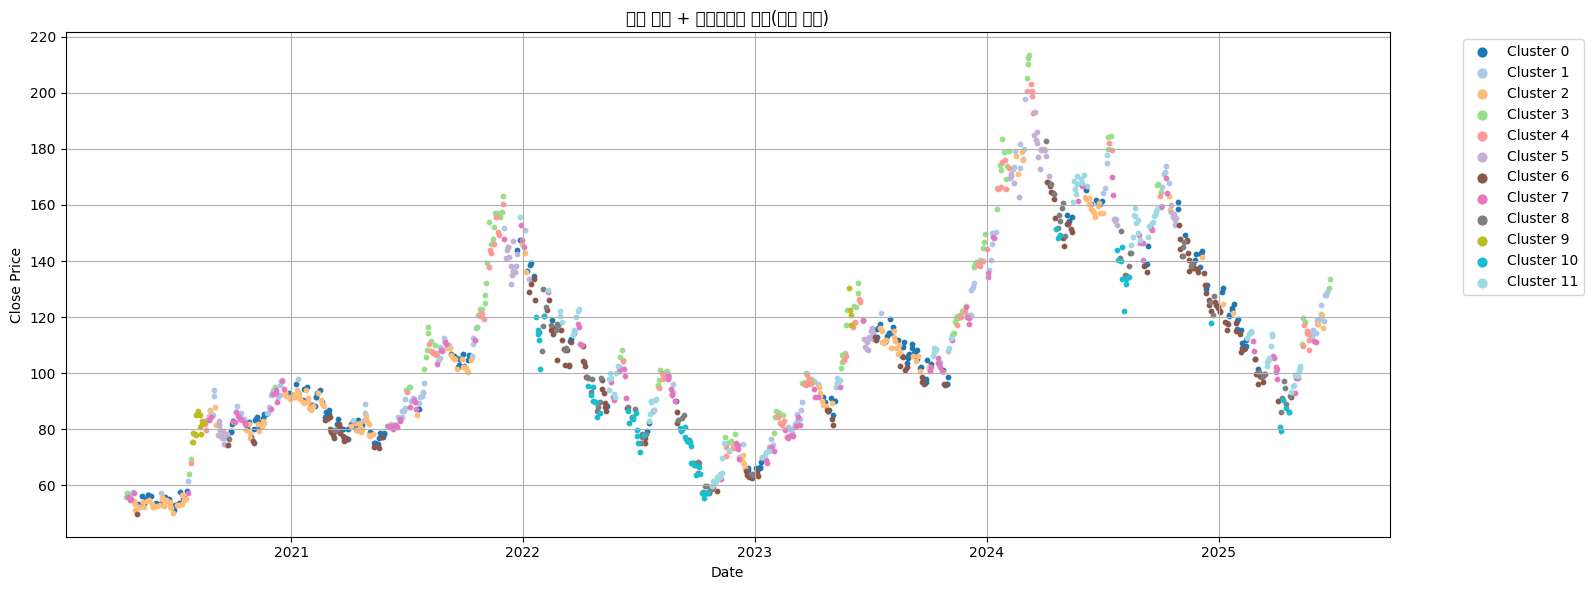

In [257]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 클러스터 수
unique_clusters = sorted(scaled_df['cluster'].unique())
n_clusters = len(unique_clusters)

# 컬러맵 정의
colors = cm.tab20(np.linspace(0, 1, n_clusters))
color_map = dict(zip(unique_clusters, colors))

# 시각화
plt.figure(figsize=(16, 6))
for cluster_id in unique_clusters:
    subset = price_cluster_df[price_cluster_df['cluster'] == cluster_id]
    plt.scatter(subset.index, subset['Close'], 
                color=color_map[cluster_id],
                s=10, label=f"Cluster {cluster_id}")

plt.title("종가 차트 + 클러스터별 색상(범례 포함)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')  # 범례 밖에 배치
plt.grid(True)
plt.tight_layout()
plt.show()


In [258]:
# 클러스터별 빈도수 확인
cluster_counts = scaled_df['cluster'].value_counts().sort_index()

print("클러스터별 출현 빈도:")
print(cluster_counts)


클러스터별 출현 빈도:
cluster
0     208
1     135
2     154
3     116
4      82
5      69
6     140
7     139
8      83
9      17
10     62
11     99
Name: count, dtype: int64


In [259]:
# 원본 종가 데이터 불러오기
close_df = df[['Close']].copy()

# 클러스터 병합
close_df = close_df.merge(scaled_df['cluster'], left_index=True, right_index=True)

# 수익률 계산 함수
def compute_future_returns(price_series, days_ahead=[5, 10, 20, 40, 60]):
    result = pd.DataFrame(index=price_series.index)
    for d in days_ahead:
        result[f'return_t+{d}'] = price_series.shift(-d) / price_series - 1
    return result

# 수익률 계산
future_returns = compute_future_returns(close_df['Close'])

# 클러스터 정보 결합
returns_cluster_df = pd.concat([close_df['cluster'], future_returns], axis=1).dropna()


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/908282740.py:17: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/908282740.py:17: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/908282740.py:17: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/908282740.py:17: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/908282740.py:17: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykerne

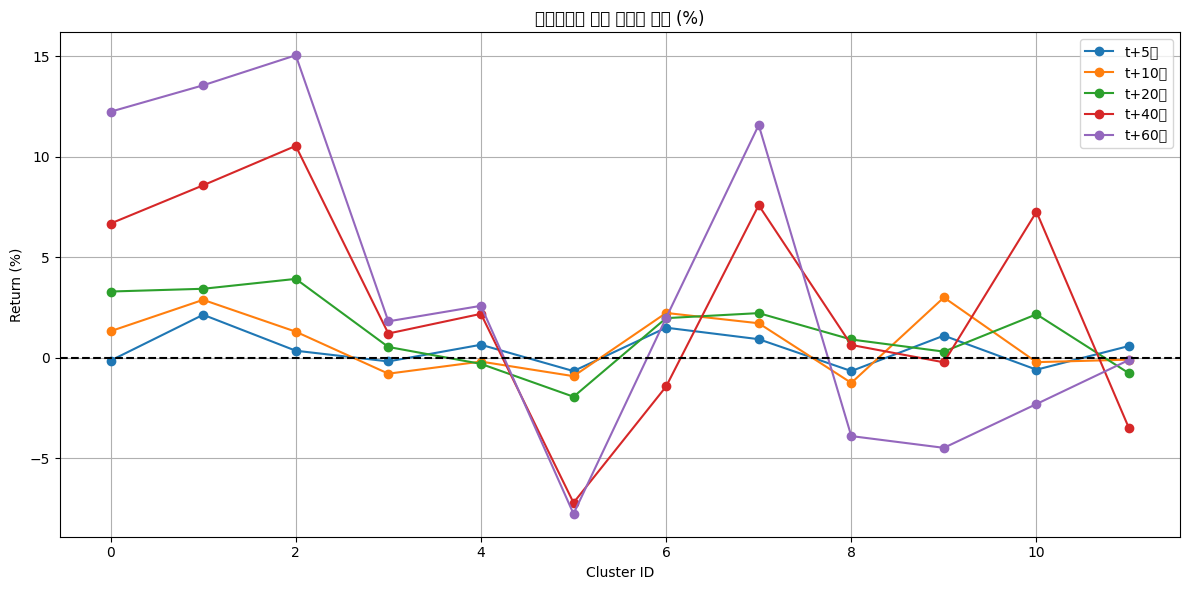

In [260]:
import matplotlib.pyplot as plt

# 클러스터별 평균 수익률 계산
mean_returns = returns_cluster_df.groupby('cluster').mean()

# 시각화
plt.figure(figsize=(12, 6))
for d in [5, 10, 20, 40, 60]:
    plt.plot(mean_returns.index, mean_returns[f'return_t+{d}'] * 100, marker='o', label=f't+{d}일')

plt.axhline(0, color='black', linestyle='--')
plt.title("클러스터별 미래 수익률 평균 (%)")
plt.xlabel("Cluster ID")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [261]:
# 클러스터별 수익률 평균 테이블
display(mean_returns)


,return_t+5,return_t+10,return_t+20,return_t+40,return_t+60
cluster,,,,,
0,-0.001374,0.013249,0.032965,0.066771,0.122360
1,0.021417,0.028834,0.034332,0.085780,0.135494
2,0.003538,0.013006,0.039246,0.105365,0.150423
3,-0.001786,-0.007876,0.005398,0.012092,0.018145
4,0.006508,-0.001861,-0.003003,0.021868,0.025859
5,-0.006586,-0.009111,-0.019336,-0.072034,-0.077534
6,0.014988,0.022315,0.019735,-0.014250,0.019883
7,0.009269,0.017188,0.022230,0.075867,0.115721
8,-0.006583,-0.012461,0.009119,0.006404,-0.038902


In [262]:
# 1. Sharpe 계산용: 원본 수익률에서 먼저 분리
mean_returns_raw = returns_cluster_df.groupby('cluster').mean()
std_returns_raw = returns_cluster_df.groupby('cluster').std()
sharpe_ratio = mean_returns_raw / std_returns_raw
sharpe_ratio.columns = [f"{col}_sharpe" for col in sharpe_ratio.columns]

# 2. 이후 각 컬럼 접미사 붙이기
mean_returns = mean_returns_raw.copy()
mean_returns.columns = [f"{col}_mean" for col in mean_returns.columns]

std_returns = std_returns_raw.copy()
std_returns.columns = [f"{col}_std" for col in std_returns.columns]



In [263]:
# 3. 통합
summary_df = pd.concat([mean_returns, std_returns, sharpe_ratio], axis=1)



In [264]:
summary_df.head()

,return_t+5_mean,return_t+10_mean,return_t+20_mean,return_t+40_mean,return_t+60_mean,return_t+5_std,return_t+10_std,return_t+20_std,return_t+40_std,return_t+60_std,return_t+5_sharpe,return_t+10_sharpe,return_t+20_sharpe,return_t+40_sharpe,return_t+60_sharpe
cluster,,,,,,,,,,,,,,,
0,-0.001374,0.013249,0.032965,0.066771,0.122360,0.062132,0.097410,0.158650,0.230455,0.283385,-0.022120,0.136010,0.207783,0.289735,0.431780
1,0.021417,0.028834,0.034332,0.085780,0.135494,0.081619,0.110396,0.138886,0.200148,0.244415,0.262401,0.261190,0.247199,0.428584,0.554361
2,0.003538,0.013006,0.039246,0.105365,0.150423,0.052167,0.089062,0.142541,0.246556,0.264417,0.067818,0.146033,0.275334,0.427348,0.568885
3,-0.001786,-0.007876,0.005398,0.012092,0.018145,0.072567,0.106295,0.151144,0.202580,0.247588,-0.024618,-0.074095,0.035712,0.059691,0.073286
4,0.006508,-0.001861,-0.003003,0.021868,0.025859,0.070424,0.094826,0.142694,0.194424,0.212873,0.092417,-0.019626,-0.021042,0.112476,0.121476


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/192906799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_df.index, y=summary_df['return_t+60_sharpe'], palette='viridis')
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/192906799.py:8: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/192906799.py:8: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/192906799.py:8: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/192906799.py:8: User

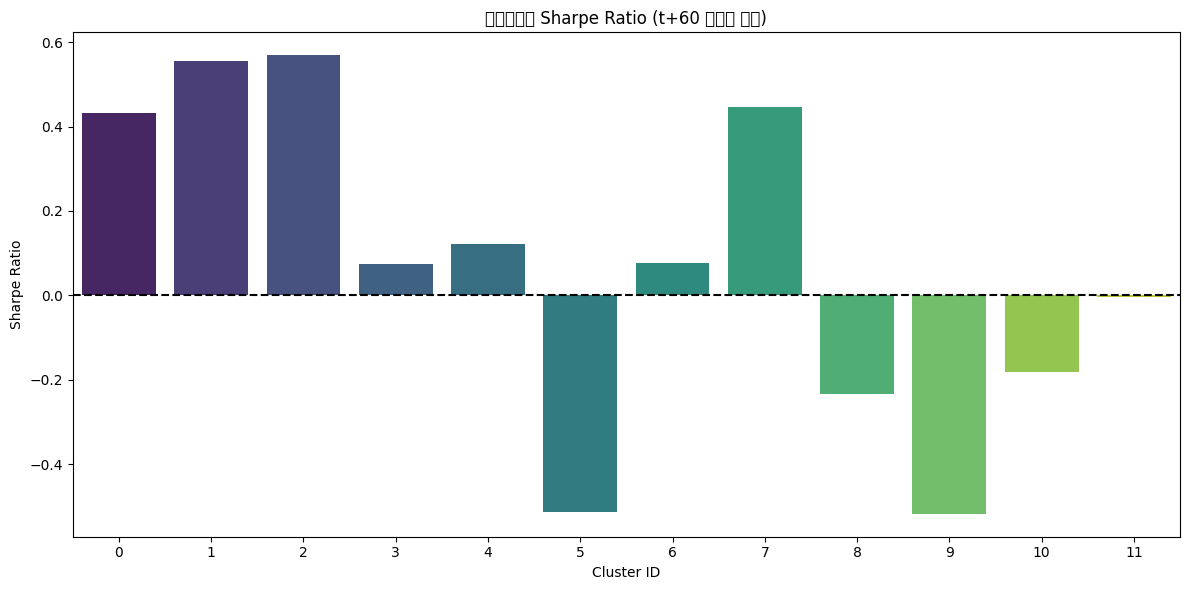

In [265]:
# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=summary_df.index, y=summary_df['return_t+60_sharpe'], palette='viridis')
plt.axhline(0, color='black', linestyle='--')
plt.title("클러스터별 Sharpe Ratio (t+60 수익률 기준)")
plt.xlabel("Cluster ID")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1246939729.py:14: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1246939729.py:14: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1246939729.py:14: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1246939729.py:14: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1246939729.py:14: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipy

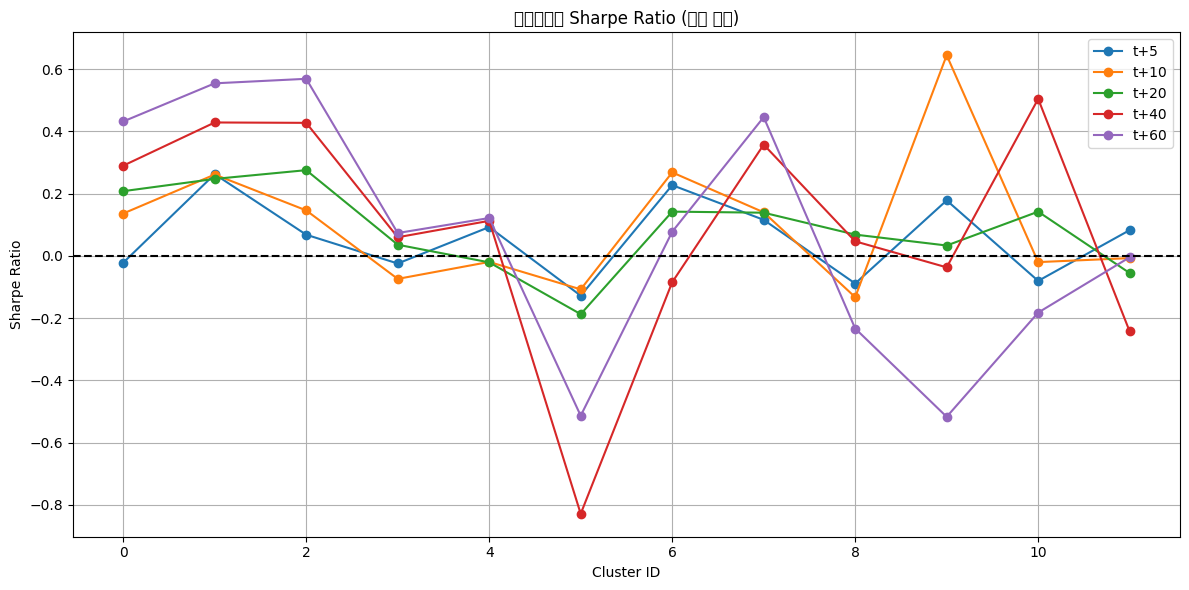

In [266]:
# 전체 시점에 대한 Sharpe ratio 라인그래프
plt.figure(figsize=(12, 6))
time_points = ['t+5', 't+10', 't+20', 't+40', 't+60']

for tp in time_points:
    plt.plot(summary_df.index, summary_df[f'return_{tp}_sharpe'], marker='o', label=tp)

plt.axhline(0, color='black', linestyle='--')
plt.title("클러스터별 Sharpe Ratio (모든 시점)")
plt.xlabel("Cluster ID")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [267]:
"""
“클러스터 X에 속했을 때, x일 후 수익률의 **위험 대비 보상(Sharpe ratio)**이 얼마인가?”를 보여줌

장기적 수익을 판단하는 기준으로 가장 많이 쓰이는 게 t+60 같은 중기/장기 시점임.
단기 수익률은 노이즈 영향이 커서 Sharpe 신뢰도가 낮음
지금 전략의 궁극 목표는 강한 상승 흐름을 구별하고 진입 시점 식별하는 것
이때 단기보다 t+60 시점의 리스크 대비 수익이 가장 신뢰도 높음

"""

'\n“클러스터 X에 속했을 때, x일 후 수익률의 **위험 대비 보상(Sharpe ratio)**이 얼마인가?”를 보여줌\n\n장기적 수익을 판단하는 기준으로 가장 많이 쓰이는 게 t+60 같은 중기/장기 시점임.\n단기 수익률은 노이즈 영향이 커서 Sharpe 신뢰도가 낮음\n지금 전략의 궁극 목표는 강한 상승 흐름을 구별하고 진입 시점 식별하는 것\n이때 단기보다 t+60 시점의 리스크 대비 수익이 가장 신뢰도 높음\n\n'

In [ ]:
#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

In [ ]:
#결과 비교를 위해 kmean 말고 hdbscan도 진행.

HDBSCAN (PCA 기반) 군집 분포:
pca_hdbscan_cluster
-1    292
 0     39
 1     17
 2     14
 3     14
 4     32
 5     17
 6    857
 7     22
Name: count, dtype: int64


/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


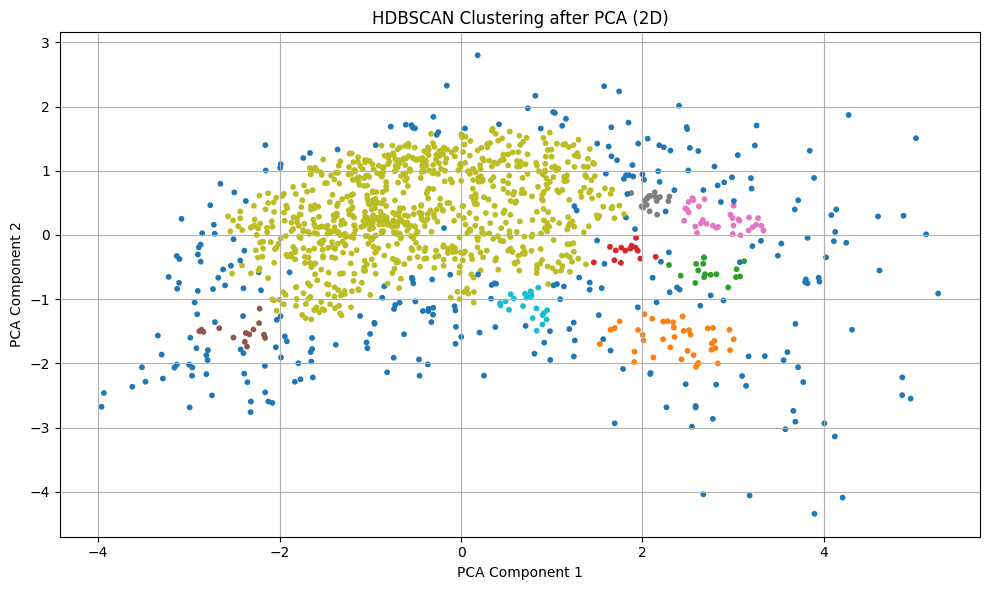

In [268]:
from sklearn.decomposition import PCA
import hdbscan
import matplotlib.pyplot as plt

# 1. PCA 적용 (2차원 축소)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_df[final_features])

# 2. HDBSCAN 재적용
hdb_pca_model = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
hdb_pca_labels = hdb_pca_model.fit_predict(pca_features)

# 3. 군집 결과 저장 (원본 인덱스 유지)
scaled_df['pca_hdbscan_cluster'] = hdb_pca_labels

# 4. 군집 개수 출력
print("HDBSCAN (PCA 기반) 군집 분포:")
print(scaled_df['pca_hdbscan_cluster'].value_counts().sort_index())

# 5. 시각화
plt.figure(figsize=(10, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], 
            c=hdb_pca_labels, cmap='tab10', s=10)
plt.title("HDBSCAN Clustering after PCA (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [269]:
# PCA 기반 HDBSCAN 클러스터 레이블을 원본 종가 데이터에 병합
close_df_pca_hdbscan = df[['Close']].copy()
close_df_pca_hdbscan['pca_hdbscan_cluster'] = scaled_df['pca_hdbscan_cluster']


In [270]:
# 수익률 계산 함수 재사용
def compute_future_returns(price_series, days_ahead=[5, 10, 20, 40, 60]):
    result = pd.DataFrame(index=price_series.index)
    for d in days_ahead:
        result[f'return_t+{d}'] = price_series.shift(-d) / price_series - 1
    return result

# 수익률 계산
future_returns_pca_hdbscan = compute_future_returns(close_df_pca_hdbscan['Close'])

# 클러스터 정보 결합
returns_pca_hdbscan_df = pd.concat([
    close_df_pca_hdbscan['pca_hdbscan_cluster'],
    future_returns_pca_hdbscan
], axis=1).dropna()


In [272]:
# 평균 수익률
mean_returns_pca_hdbscan = returns_pca_hdbscan_df.groupby('pca_hdbscan_cluster').mean()
mean_returns_pca_hdbscan.columns = [f"return_t+{d}_mean" for d in [5, 10, 20, 40, 60]]

# 표준편차
std_returns_pca_hdbscan = returns_pca_hdbscan_df.groupby('pca_hdbscan_cluster').std()
std_returns_pca_hdbscan.columns = [f"return_t+{d}_std" for d in [5, 10, 20, 40, 60]]

# Sharpe Ratio 계산
sharpe_ratio_pca_hdbscan = mean_returns_pca_hdbscan.values / std_returns_pca_hdbscan.values
sharpe_ratio_pca_hdbscan = pd.DataFrame(
    sharpe_ratio_pca_hdbscan,
    index=mean_returns_pca_hdbscan.index,
    columns=[f"return_t+{d}_sharpe" for d in [5, 10, 20, 40, 60]]
)

# 통합 요약 테이블
summary_pca_hdbscan_df = pd.concat([
    mean_returns_pca_hdbscan,
    std_returns_pca_hdbscan,
    sharpe_ratio_pca_hdbscan
], axis=1)


In [273]:
summary_pca_hdbscan_df.head()


,return_t+5_mean,return_t+10_mean,return_t+20_mean,return_t+40_mean,return_t+60_mean,return_t+5_std,return_t+10_std,return_t+20_std,return_t+40_std,return_t+60_std,return_t+5_sharpe,return_t+10_sharpe,return_t+20_sharpe,return_t+40_sharpe,return_t+60_sharpe
pca_hdbscan_cluster,,,,,,,,,,,,,,,
-1.0,0.005276,0.005466,-0.005409,0.001112,-0.011608,0.073723,0.098229,0.138257,0.176161,0.200340,0.071559,0.055647,-0.039119,0.006312,-0.057941
0.0,0.005204,-0.003030,-0.007751,0.051398,0.024365,0.080159,0.094249,0.142270,0.213590,0.223071,0.064916,-0.032152,-0.054477,0.240636,0.109225
1.0,-0.016685,-0.039774,0.034221,0.078726,0.114931,0.059026,0.090027,0.140993,0.253336,0.280387,-0.282675,-0.441800,0.242716,0.310759,0.409902
2.0,-0.002838,-0.008140,0.021441,0.062171,0.079406,0.042285,0.077202,0.127887,0.159330,0.236519,-0.067112,-0.105443,0.167658,0.390203,0.335726
3.0,-0.042488,-0.094201,-0.121657,-0.048904,-0.070080,0.060275,0.070611,0.148521,0.109972,0.100317,-0.704896,-1.334080,-0.819124,-0.444698,-0.698587


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1124912303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_pca_hdbscan_df.index.astype(str),
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1124912303.py:13: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1124912303.py:13: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1124912303.py:13: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1124912303.py:13: UserWarning: Glyph 53552 (

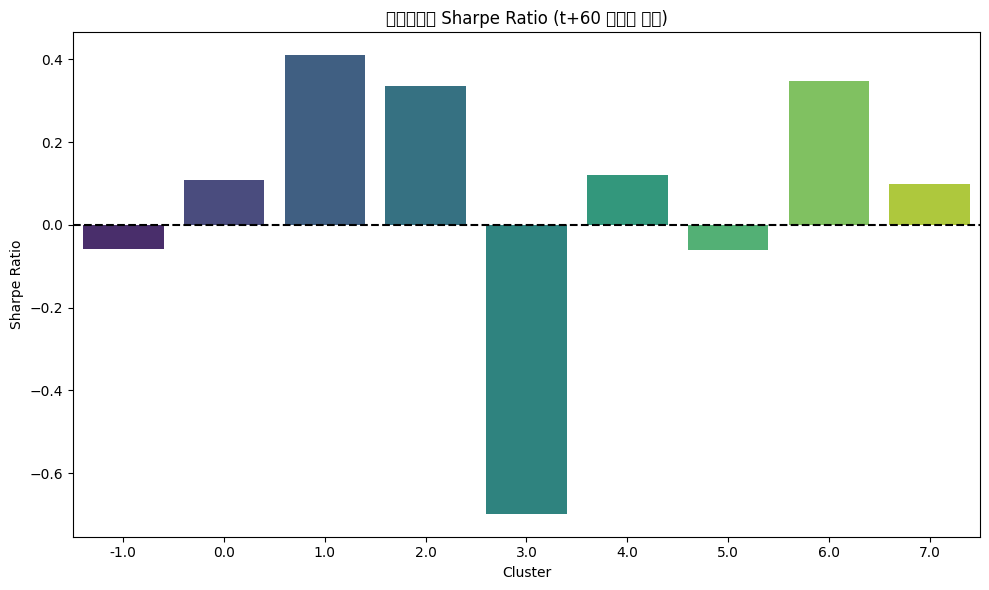

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

# t+60 기준 Sharpe 비율 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_pca_hdbscan_df.index.astype(str),
            y=summary_pca_hdbscan_df['return_t+60_sharpe'],
            palette='viridis')
plt.axhline(0, color='black', linestyle='--')
plt.title("클러스터별 Sharpe Ratio (t+60 수익률 기준)")
plt.xlabel("Cluster")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.show()


In [ ]:
"""
| Cluster  | Sharpe Ratio (t+60) | 인사이트 요약                               |
| -------- | ------------------- | ------------------------------------- |
| **1**    | **0.41**            | **장기 수익률 및 안정성 모두 우수. 강력한 매수 신호 구간.** |
| **6**    | **0.40+**           | 대규모 클러스터에서 가장 이상적인 상승 패턴. 주력 진입 후보.   |
| **2**    | 0.34                | 변동성은 존재하나 중장기에서 안정적 수익 추구 가능          |
| **4, 7** | 0.10대               | 애매한 수익률/변동성. 전략 보완 전엔 진입 보류 필요        |
| **0, 5** | 약 0 \~ 음수           | 수익 불안정성 존재. 회피 추천                     |
| **3**    | **-0.67**           | **장기 손실 지속 구간. 철저한 회피 구간으로 분류.**      |
| **-1**   | -0.04               | **Noise 군집**: 전략적 필터링 필요 (예측 불가능)     |

"""

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3610988077.py:41: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3610988077.py:41: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3610988077.py:41: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3610988077.py:41: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/3610988077.py:41: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ip

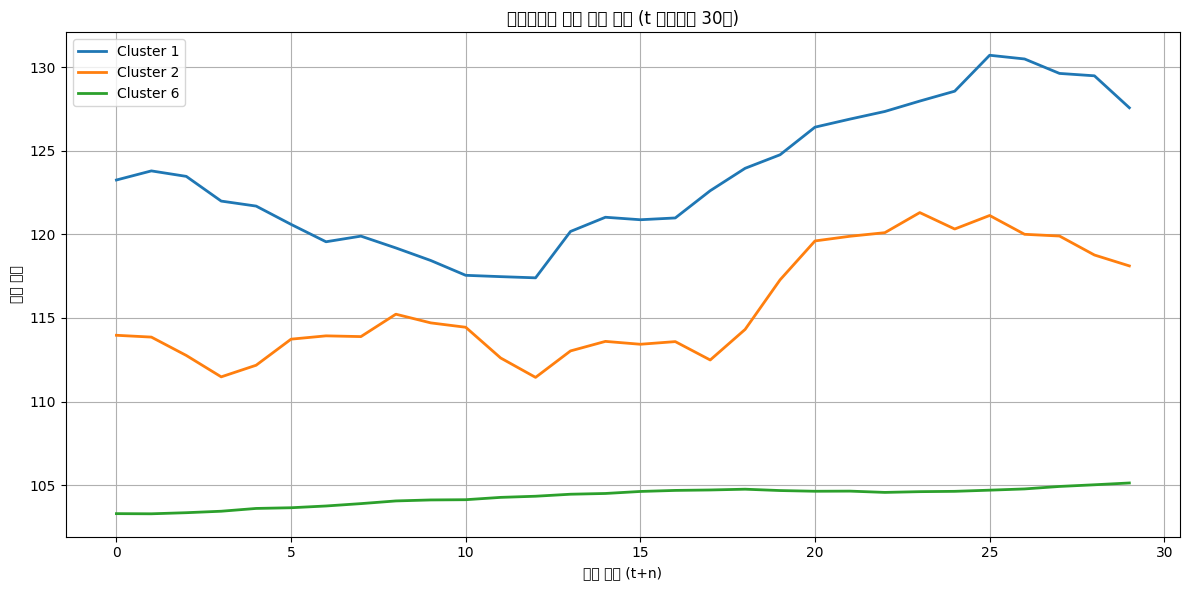

In [277]:
import matplotlib.pyplot as plt

# 1. 이동 평균 계산 함수 수정
def get_cluster_price_series(index_list, full_price_series, window=30):
    aligned = []
    full_index = full_price_series.index

    for timestamp in index_list:
        # 인덱스 위치를 정수 위치로 변환
        if timestamp in full_index:
            loc = full_index.get_loc(timestamp)
            # 슬라이싱이 가능한 범위 내에서만
            if loc + window <= len(full_price_series):
                series = full_price_series.iloc[loc:loc + window]
                aligned.append(series.values)
    
    # 평균 시계열 생성
    return pd.DataFrame(aligned).mean()

# 2. 클러스터별 인덱스 추출
cluster_1_idx = close_df_pca_hdbscan[close_df_pca_hdbscan['pca_hdbscan_cluster'] == 1].index
cluster_2_idx = close_df_pca_hdbscan[close_df_pca_hdbscan['pca_hdbscan_cluster'] == 2].index
cluster_6_idx = close_df_pca_hdbscan[close_df_pca_hdbscan['pca_hdbscan_cluster'] == 6].index

# 3. 평균 종가 흐름 계산
window = 30
avg_close_1 = get_cluster_price_series(cluster_1_idx, df['Close'], window)
avg_close_2 = get_cluster_price_series(cluster_2_idx, df['Close'], window)
avg_close_6 = get_cluster_price_series(cluster_6_idx, df['Close'], window)

# 4. 시각화
plt.figure(figsize=(12, 6))
plt.plot(avg_close_1.values, label='Cluster 1', linewidth=2)
plt.plot(avg_close_2.values, label='Cluster 2', linewidth=2)
plt.plot(avg_close_6.values, label='Cluster 6', linewidth=2)
plt.title('클러스터별 평균 종가 흐름 (t 시점부터 30일)')
plt.xlabel('경과 일수 (t+n)')
plt.ylabel('평균 종가')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:27: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:27: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:27: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:27: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykerne

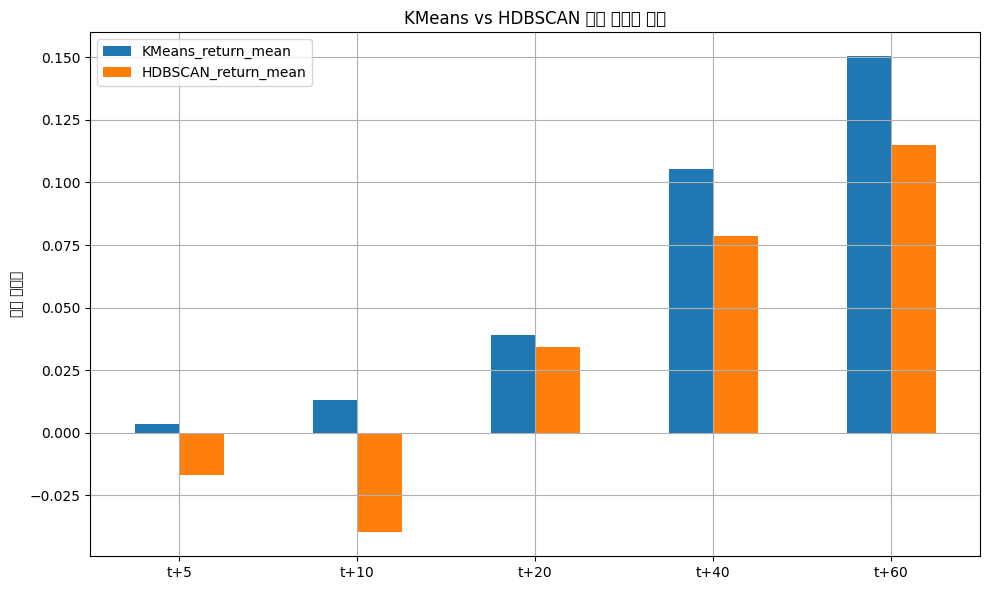

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:36: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/478963171.py:36: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


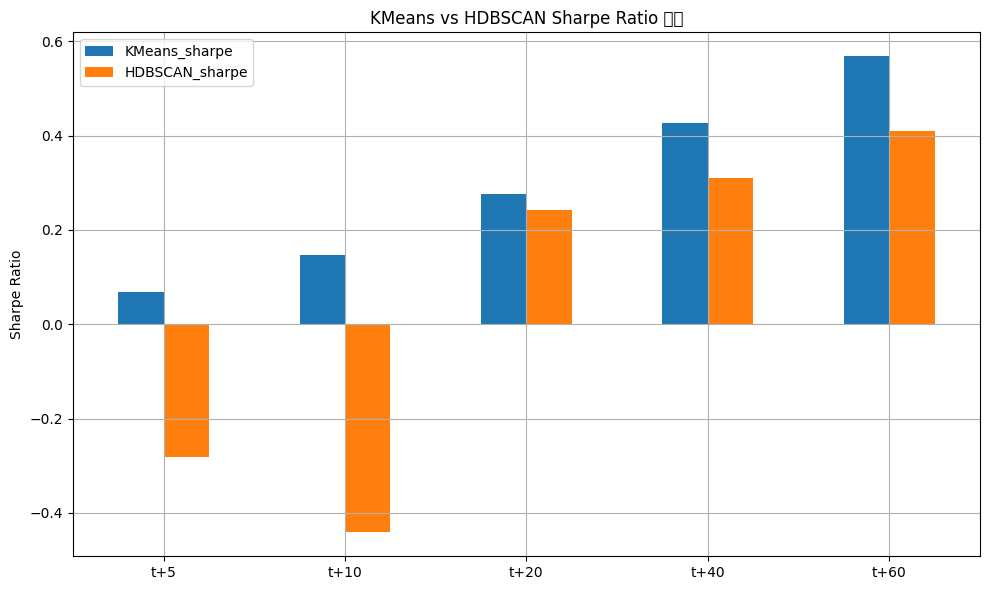

In [282]:
# 각 방법의 Sharpe 기준 최고 성능 클러스터 인덱스
best_kmeans_idx = summary_df['return_t+60_sharpe'].idxmax()
best_hdbscan_idx = summary_pca_hdbscan_df['return_t+60_sharpe'].idxmax()

# 기준 열 정의
cols_return = [f'return_t+{n}_mean' for n in [5, 10, 20, 40, 60]]
cols_sharpe = [f'return_t+{n}_sharpe' for n in [5, 10, 20, 40, 60]]
index_labels = [f't+{n}' for n in [5, 10, 20, 40, 60]]

# 값 추출 후 DataFrame 생성
compare_metrics = pd.DataFrame({
    'KMeans_return_mean': summary_df.loc[best_kmeans_idx, cols_return].values,
    'KMeans_sharpe': summary_df.loc[best_kmeans_idx, cols_sharpe].values,
    'HDBSCAN_return_mean': summary_pca_hdbscan_df.loc[best_hdbscan_idx, cols_return].values,
    'HDBSCAN_sharpe': summary_pca_hdbscan_df.loc[best_hdbscan_idx, cols_sharpe].values,
}, index=index_labels)


import matplotlib.pyplot as plt

# 평균 수익률 비교
compare_metrics[['KMeans_return_mean', 'HDBSCAN_return_mean']].plot(
    kind='bar', figsize=(10, 6), title='KMeans vs HDBSCAN 평균 수익률 비교')
plt.ylabel("평균 수익률")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# Sharpe Ratio 비교
compare_metrics[['KMeans_sharpe', 'HDBSCAN_sharpe']].plot(
    kind='bar', figsize=(10, 6), title='KMeans vs HDBSCAN Sharpe Ratio 비교')
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:30: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:30: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:30: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:30: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:30: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipy

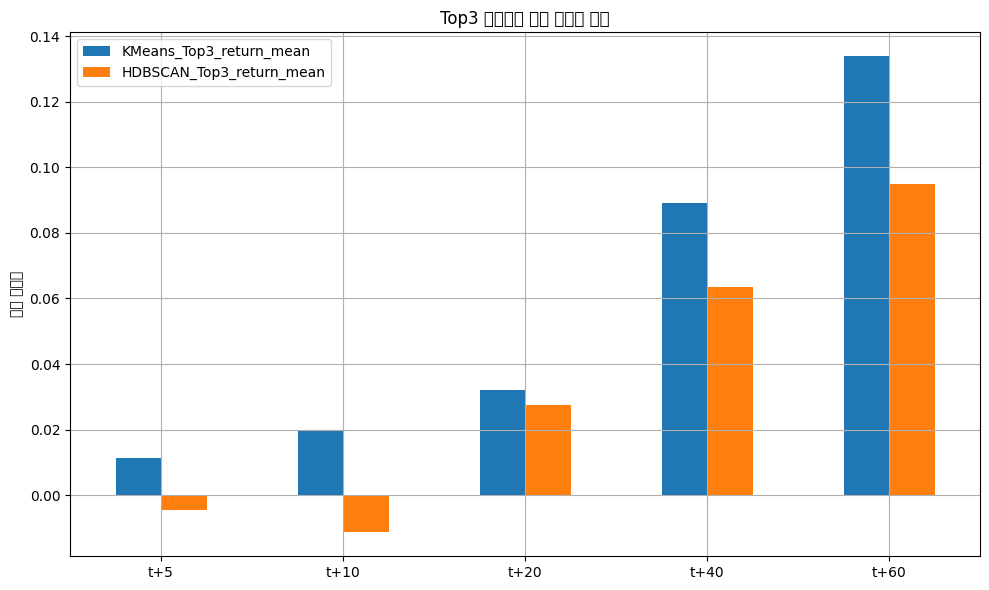

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:39: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:39: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:39: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:39: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_21984/1294492463.py:39: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ip

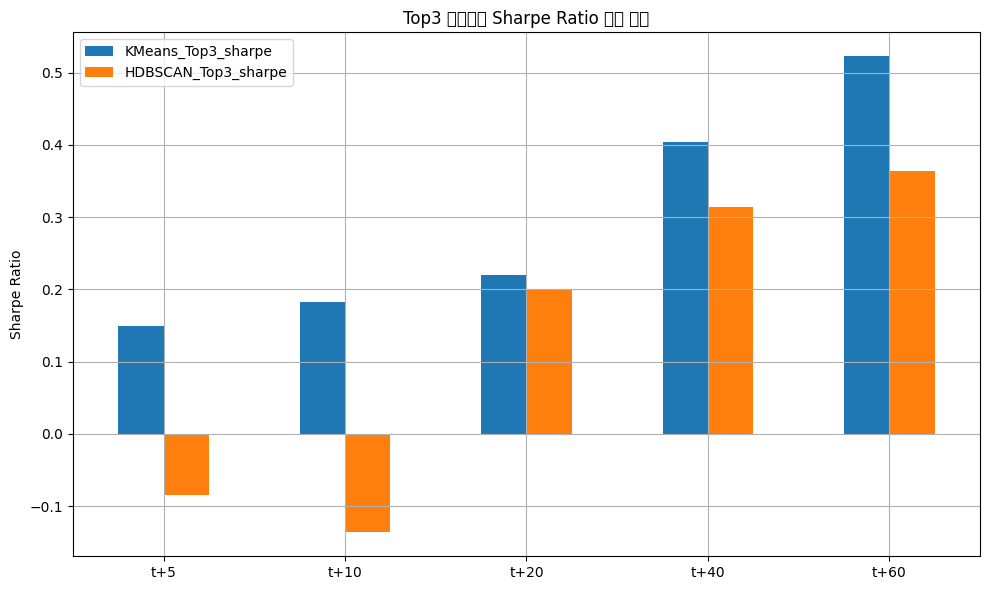

In [285]:
# 1. 상위 3개 클러스터 인덱스 추출
top3_kmeans_idx = summary_df['return_t+60_sharpe'].nlargest(3).index
top3_hdbscan_idx = summary_pca_hdbscan_df['return_t+60_sharpe'].nlargest(3).index

# 2. 수익률 및 Sharpe 컬럼 정의
cols_return = [f'return_t+{n}_mean' for n in [5, 10, 20, 40, 60]]
cols_sharpe = [f'return_t+{n}_sharpe' for n in [5, 10, 20, 40, 60]]
index_labels = [f't+{n}' for n in [5, 10, 20, 40, 60]]

# 3. 평균값 계산
mean_kmeans_return = summary_df.loc[top3_kmeans_idx, cols_return].mean()
mean_kmeans_sharpe = summary_df.loc[top3_kmeans_idx, cols_sharpe].mean()
mean_hdbscan_return = summary_pca_hdbscan_df.loc[top3_hdbscan_idx, cols_return].mean()
mean_hdbscan_sharpe = summary_pca_hdbscan_df.loc[top3_hdbscan_idx, cols_sharpe].mean()

# 4. 비교용 데이터프레임 생성
compare_top3_metrics = pd.DataFrame({
    'KMeans_Top3_return_mean': mean_kmeans_return.values,
    'KMeans_Top3_sharpe': mean_kmeans_sharpe.values,
    'HDBSCAN_Top3_return_mean': mean_hdbscan_return.values,
    'HDBSCAN_Top3_sharpe': mean_hdbscan_sharpe.values
}, index=index_labels)

# 5. 시각화 - 평균 수익률
compare_top3_metrics[['KMeans_Top3_return_mean', 'HDBSCAN_Top3_return_mean']].plot(
    kind='bar', figsize=(10, 6), title='Top3 클러스터 평균 수익률 비교')
plt.ylabel("평균 수익률")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. 시각화 - Sharpe Ratio
compare_top3_metrics[['KMeans_Top3_sharpe', 'HDBSCAN_Top3_sharpe']].plot(
    kind='bar', figsize=(10, 6), title='Top3 클러스터 Sharpe Ratio 평균 비교')
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#---------------------------------------------------------------------
#---------------------------------------------------------------------
#---------------------------------------------------------------------
# kmeans가 압도적 성과 -> k means로 분석하기로 결정.


In [309]:
import joblib

# 1. 저장
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# 2. 불러올 때는 아래처럼 사용
# kmeans = joblib.load('kmeans_model.pkl')
# scaler = joblib.load('scaler.pkl')


['scaler.pkl']